# Hurricane Track Generation with LSTM-VAE

This notebook now uses an object-oriented structure for hurricane data and generation:

- `Hurricane`: Base class for hurricane tracks (common attributes, plotting, summary).
- `HistoricHurricane`: For real hurricanes parsed from HURDAT2.
- `SyntheticHurricane`: For synthetic hurricanes generated by LSTM-VAE.
- `HurricaneLSTMVAE`: Model class for LSTM-VAE.

This structure improves modularity, clarity, and extensibility.

In [8]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.saving import register_keras_serializable
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import pickle
import re
import os
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Check TensorFlow version
print(f"TensorFlow version: {tf.__version__}")

# Enable memory growth on GPUs if available
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Found {len(gpus)} GPU(s), memory growth enabled")
    except RuntimeError as e:
        print(f"GPU setup error: {e}")
else:
    print("No GPUs found, running on CPU")

TensorFlow version: 2.19.0
No GPUs found, running on CPU


## Object-Oriented Hurricane Classes

We define a base `Hurricane` class, and two subclasses: `HistoricHurricane` and `SyntheticHurricane`.

In [9]:
# filepath: project_folder/Wind/Hurricane/Hurricane-LSTM-VAE V1.ipynb
class Hurricane:
    def __init__(self, track_df):
        self.track_df = track_df

    def plot(self, title="Hurricane Track"):
        fig = plt.figure(figsize=(15, 10))
        ax = plt.axes(projection=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.add_feature(cfeature.STATES, linestyle=':')
        ax.set_extent([-100, -50, 10, 50], crs=ccrs.PlateCarree())
        try:
            osm_tiles = cimgt.OSM()
            ax.add_image(osm_tiles, 8)
        except Exception:
            pass
        plt.plot(self.track_df['longitude'], self.track_df['latitude'],
                 '-o', markersize=4, label=getattr(self, 'storm_name', 'Track'), transform=ccrs.PlateCarree())
        scatter = plt.scatter(self.track_df['longitude'], self.track_df['latitude'],
                              c=self.track_df['max_wind'], cmap='YlOrRd', transform=ccrs.PlateCarree())
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Maximum Wind Speed (knots)')
        plt.title(title)
        plt.legend(loc='upper right')
        plt.grid(True)
        plt.show()

    def summary(self):
        print(self.track_df.describe())

class HistoricHurricane(Hurricane):
    @classmethod
    def from_hurdat2(cls, hurdat2_file, storm_id):
        handler = HurricaneDataHandler(hurdat2_file)
        df = handler.select_hurricane(storm_id)
        obj = cls(df)
        obj.storm_name = df['storm_name'].iloc[0] if not df.empty else storm_id
        return obj

    @staticmethod
    def get_training_sequences(hurdat2_file, **kwargs):
        handler = HurricaneDataHandler(hurdat2_file)
        return handler.prepare_training_data(**kwargs)

class SyntheticHurricane(Hurricane):
    @classmethod
    def generate(cls, vae_model, num_points=None, seed_features=None, randomness=0.5):
        track_df = vae_model.generate_hurricane(num_points=num_points, seed_hurricane_features=seed_features, randomness=randomness)
        obj = cls(track_df)
        obj.storm_name = track_df['storm_name'].iloc[0]
        return obj

In [10]:
# Hurricane data parsing class - slightly modified from previous implementation
class HurricaneDataHandler:
    def __init__(self, hurdat2_file):
        self.hurdat2_file = hurdat2_file
        self.hurdat_df = self.parse_hurdat2()
        
    def parse_hurdat2(self):
        """Parse the HURDAT2 format file into a pandas DataFrame"""
        with open(self.hurdat2_file, 'r') as f:
            file_content = f.read()
        
        lines = file_content.strip().split('\n')
        data = []
        current_header = None
        
        for line in lines:
            if re.match(r'^[A-Z]{2}\d{6}', line):
                parts = line.split(',')
                basin_id = parts[0].strip()
                basin = basin_id[:2]
                cyclone_number = basin_id[2:4]
                year = basin_id[4:8]
                name = parts[1].strip()
                num_entries = int(parts[2].strip())
                current_header = {
                    'basin': basin,
                    'cyclone_number': cyclone_number,
                    'year': year,
                    'full_id': basin_id,
                    'name': name,
                    'num_entries': num_entries
                }
            else:
                if current_header:
                    parts = line.split(',')
                    date_str = parts[0].strip()
                    time_str = parts[1].strip()
                    year = int(date_str[0:4])
                    month = int(date_str[4:6])
                    day = int(date_str[6:8])
                    hour = int(time_str[0:2]) if time_str else 0
                    minute = int(time_str[2:4]) if len(time_str) >= 4 else 0
                    record_id = parts[2].strip()
                    status = parts[3].strip()
                    lat_str = parts[4].strip()
                    lon_str = parts[5].strip()
                    lat = float(lat_str[:-1]) * (1 if lat_str[-1] == 'N' else -1)
                    lon = float(lon_str[:-1]) * (-1 if lon_str[-1] == 'W' else 1)
                    max_wind = int(parts[6].strip()) if parts[6].strip() not in ['-999', ''] else None
                    min_pressure = int(parts[7].strip()) if parts[7].strip() not in ['-999', ''] else None
                    
                    # Parse wind radii if available (34kt, 50kt, 64kt)
                    ne_34kt = int(parts[8].strip()) if len(parts) > 8 and parts[8].strip() not in ['-999', ''] else None
                    se_34kt = int(parts[9].strip()) if len(parts) > 9 and parts[9].strip() not in ['-999', ''] else None
                    sw_34kt = int(parts[10].strip()) if len(parts) > 10 and parts[10].strip() not in ['-999', ''] else None
                    nw_34kt = int(parts[11].strip()) if len(parts) > 11 and parts[11].strip() not in ['-999', ''] else None
                    ne_50kt = int(parts[12].strip()) if len(parts) > 12 and parts[12].strip() not in ['-999', ''] else None
                    se_50kt = int(parts[13].strip()) if len(parts) > 13 and parts[13].strip() not in ['-999', ''] else None
                    sw_50kt = int(parts[14].strip()) if len(parts) > 14 and parts[14].strip() not in ['-999', ''] else None
                    nw_50kt = int(parts[15].strip()) if len(parts) > 15 and parts[15].strip() not in ['-999', ''] else None
                    ne_64kt = int(parts[16].strip()) if len(parts) > 16 and parts[16].strip() not in ['-999', ''] else None
                    se_64kt = int(parts[17].strip()) if len(parts) > 17 and parts[17].strip() not in ['-999', ''] else None
                    sw_64kt = int(parts[18].strip()) if len(parts) > 18 and parts[18].strip() not in ['-999', ''] else None
                    nw_64kt = int(parts[19].strip()) if len(parts) > 19 and parts[19].strip() not in ['-999', ''] else None
                    rmw = int(parts[20].strip()) if len(parts) > 20 and parts[20].strip() not in ['-999', ''] else None
                    
                    data.append({
                        'basin': current_header['basin'],
                        'cyclone_number': current_header['cyclone_number'],
                        'full_id': current_header['full_id'],
                        'storm_name': current_header['name'],
                        'year': year,
                        'month': month,
                        'day': day,
                        'hour': hour,
                        'minute': minute,
                        'record_id': record_id,
                        'status': status,
                        'latitude': lat,
                        'longitude': lon,
                        'max_wind': max_wind,
                        'min_pressure': min_pressure,
                        'ne_34kt_radius': ne_34kt,
                        'se_34kt_radius': se_34kt,
                        'sw_34kt_radius': sw_34kt,
                        'nw_34kt_radius': nw_34kt,
                        'ne_50kt_radius': ne_50kt,
                        'se_50kt_radius': se_50kt,
                        'sw_50kt_radius': sw_50kt,
                        'nw_50kt_radius': nw_50kt,
                        'ne_64kt_radius': ne_64kt,
                        'se_64kt_radius': se_64kt,
                        'sw_64kt_radius': sw_64kt,
                        'nw_64kt_radius': nw_64kt,
                        'radius_max_wind': rmw
                    })
        
        df = pd.DataFrame(data)
        df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute']])
        return df
    
    def prepare_training_data(self, min_wind_speed=50, min_sequence_length=5, region_filter=True):
        """
        Extract hurricane sequences suitable for LSTM-VAE training.
        Returns hurricane tracks as sequences suitable for LSTM training.
        """
        df = self.hurdat_df
        
        # Filter for hurricanes with sufficient wind speed
        strong_hurricanes = df[df['max_wind'] >= min_wind_speed]
        
        # Optionally filter by region (e.g., Atlantic hurricanes that might affect US East Coast)
        if region_filter:
            region_filter = (strong_hurricanes['latitude'] >= 10) & \
                            (strong_hurricanes['latitude'] <= 45) & \
                            (strong_hurricanes['longitude'] >= -100) & \
                            (strong_hurricanes['longitude'] <= -50)
            strong_hurricanes = strong_hurricanes[region_filter]
        
        # Handle missing values for all features
        strong_hurricanes = strong_hurricanes.dropna(subset=['latitude', 'longitude', 'max_wind'])
        strong_hurricanes = strong_hurricanes.fillna({
            'min_pressure': strong_hurricanes['min_pressure'].mean(),
            'ne_34kt_radius': 0, 'se_34kt_radius': 0, 
            'sw_34kt_radius': 0, 'nw_34kt_radius': 0,
            'ne_50kt_radius': 0, 'se_50kt_radius': 0,
            'sw_50kt_radius': 0, 'nw_50kt_radius': 0,
            'ne_64kt_radius': 0, 'se_64kt_radius': 0,
            'sw_64kt_radius': 0, 'nw_64kt_radius': 0,
            'radius_max_wind': 0
        })
        
        # Group by storm ID to get individual hurricane tracks
        grouped = strong_hurricanes.groupby('full_id')
        
        # Define all features to use (same as VAE V1)
        features = [
            'latitude', 'longitude', 'max_wind', 'min_pressure',
            'ne_34kt_radius', 'se_34kt_radius', 'sw_34kt_radius', 'nw_34kt_radius',
            'ne_50kt_radius', 'se_50kt_radius', 'sw_50kt_radius', 'nw_50kt_radius',
            'ne_64kt_radius', 'se_64kt_radius', 'sw_64kt_radius', 'nw_64kt_radius',
            'radius_max_wind'
        ]
        
        # Create a list of hurricane sequences
        hurricane_sequences = []
        hurricane_ids = []
        
        for storm_id, group in grouped:
            if len(group) >= min_sequence_length:  # Only include hurricanes with enough data points
                # Sort by datetime to ensure proper sequence
                track = group.sort_values('datetime')
                
                # Extract all features
                features_arr = track[features].values
                hurricane_sequences.append(features_arr)
                hurricane_ids.append(storm_id)
        
        print(f"Found {len(hurricane_sequences)} hurricane tracks suitable for training")
        return hurricane_sequences, hurricane_ids
    
    def select_hurricane(self, storm_id):
        """Select a specific hurricane by its ID"""
        hurricane_data = self.hurdat_df[self.hurdat_df['full_id'] == storm_id]
        if not hurricane_data.empty:
            storm_name = hurricane_data['storm_name'].iloc[0]
            print(f"Selected Hurricane: {storm_id}, {storm_name}")
        return hurricane_data
    
    def plot_hurricane_tracks(self, hurricane_data, title='Hurricane Tracks'):
        """Plot hurricane tracks on a map"""
        fig = plt.figure(figsize=(15, 10))
        ax = plt.axes(projection=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.add_feature(cfeature.STATES, linestyle=':')
        ax.set_extent([-100, -50, 10, 50], crs=ccrs.PlateCarree())

        # Add OpenStreetMap base map
        osm_tiles = cimgt.OSM()
        ax.add_image(osm_tiles, 8)

        # Plot hurricane path
        plt.plot(hurricane_data['longitude'], hurricane_data['latitude'],
                '-o', markersize=4, label=hurricane_data['storm_name'].iloc[0], transform=ccrs.PlateCarree())

        # Color points by intensity
        scatter = plt.scatter(hurricane_data['longitude'], hurricane_data['latitude'], 
                            c=hurricane_data['max_wind'], cmap='YlOrRd', 
                            transform=ccrs.PlateCarree())

        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Maximum Wind Speed (knots)')

        plt.title(title)
        plt.legend(loc='upper right')
        plt.grid(True)
        plt.show()

Found 808 hurricane tracks suitable for training
Selected Hurricane: AL182012, SANDY
Selected Hurricane: AL182012, SANDY


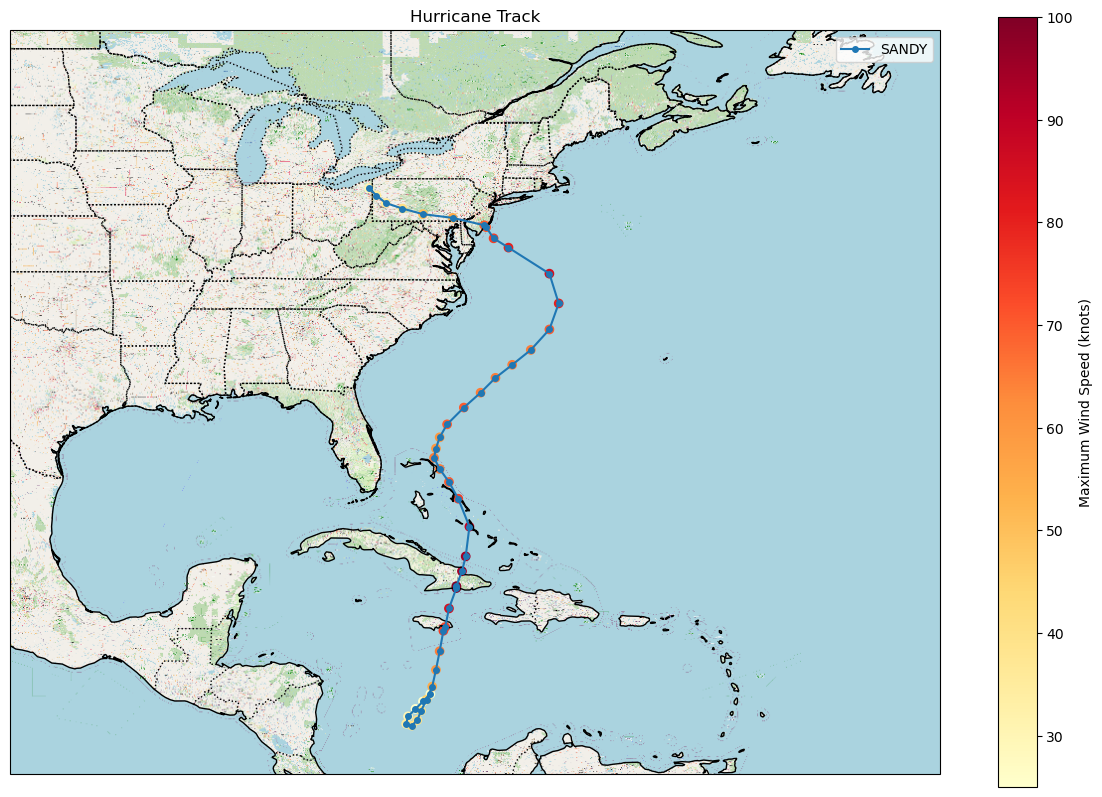

Sample sequence shape: (10, 17)
Sample sequence data (first 3 points):
[[ 25.7        -90.8         50.         976.64939173   0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.        ]
 [ 26.3        -90.4         50.         976.64939173   0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.        ]
 [ 27.         -90.          50.         976.64939173   0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.        ]]


In [11]:
# Load and prepare hurricane data using the new class structure
hurdat2_file = 'project_folder/Wind/Hurricane/NOAA HURDAT2/hurdat2-1851-2023-051124.txt'

# Prepare sequences for LSTM training
hurricane_sequences, hurricane_ids = HistoricHurricane.get_training_sequences(
    hurdat2_file, min_wind_speed=50, min_sequence_length=10
)

# Example: View a single hurricane track
sample_id = 'AL182012'
historic_hurr = HistoricHurricane.from_hurdat2(hurdat2_file, sample_id)
historic_hurr.plot()

# Print sample sequence data
print(f"Sample sequence shape: {hurricane_sequences[10].shape}")
print("Sample sequence data (first 3 points):")
print(hurricane_sequences[10][:3])

In [12]:
value_to_find = 'AL182012'

try:
  index = hurricane_ids.index(value_to_find)
  print(f"The value '{value_to_find}' is at index: {index}")
except ValueError:
  print(f"The value '{value_to_find}' is not in the list.")

The value 'AL182012' is at index: 778


## LSTM-VAE Model Implementation

The LSTM-VAE model is implemented as a separate class, and is used by `SyntheticHurricane` for generation.

In [13]:
@register_keras_serializable(package="Custom", name="sampling")
def _sampling(args):
    """Reparameterization trick for sampling from latent space"""
    z_mean, z_log_var = args
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.random.normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

class VAELossLayer(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        kl_loss = -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1)
        self.add_loss(tf.reduce_mean(kl_loss))
        return z_mean  # Return z_mean as a placeholder

class HurricaneLSTMVAE:
    def __init__(self, input_dim=17, latent_dim=32, sequence_length=None, lstm_units=64):
        """
        Initialize the LSTM-VAE model for hurricane track generation
        
        Parameters:
        -----------
        input_dim : int
            Dimension of input features at each time step
            (now 17 for all features)
        latent_dim : int
            Dimension of the latent space
        sequence_length : int or None
            Maximum sequence length (can be None for variable-length sequences)
        lstm_units : int
            Number of LSTM units in each layer
        """
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.sequence_length = sequence_length
        self.lstm_units = lstm_units
        self.scaler = MinMaxScaler()
        self.z_mean = None
        self.z_log_var = None
        self._build_model()
        
    def _reconstruction_loss_fn(self, y_true, y_pred):
        """
        Reconstruction loss for sequences (e.g., Mean Squared Error over all timesteps and features).
        """
        mse = tf.keras.losses.MeanSquaredError()
        return mse(y_true, y_pred)

    def _build_model(self):
        """Construct the LSTM-VAE model architecture"""
        # Define encoder
        encoder_inputs = keras.Input(shape=(self.sequence_length, self.input_dim), name="encoder_input")
        
        # LSTM encoder layers
        x = layers.LSTM(self.lstm_units, return_sequences=True, name="encoder_lstm_1")(encoder_inputs)
        x = layers.LSTM(self.lstm_units, name="encoder_lstm_2")(x)
        
        # Define latent space parameters
        self.z_mean = layers.Dense(self.latent_dim, name="z_mean")(x)
        self.z_log_var = layers.Dense(self.latent_dim, name="z_log_var")(x)
        
        # Sampling layer using reparameterization trick
        z = layers.Lambda(_sampling, name="z_sampling")([self.z_mean, self.z_log_var])
        
        # Add the custom KL loss layer
        _ = VAELossLayer()([self.z_mean, self.z_log_var])
        
        # Define encoder model
        self.encoder = keras.Model(encoder_inputs, [self.z_mean, self.z_log_var, z], name="encoder")
        print("Encoder model summary:")
        self.encoder.summary()
        
        # Define decoder
        latent_inputs = keras.Input(shape=(self.latent_dim,), name="decoder_latent_input")
        x = layers.RepeatVector(self.sequence_length, name="repeat_vector")(latent_inputs)
        x = layers.LSTM(self.lstm_units, return_sequences=True, name="decoder_lstm_1")(x)
        x = layers.LSTM(self.lstm_units, return_sequences=True, name="decoder_lstm_2")(x)
        decoder_outputs = layers.TimeDistributed(layers.Dense(self.input_dim), name="decoder_output_timedistributed")(x)
        
        # Define decoder model
        self.decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
        print("\nDecoder model summary:")
        self.decoder.summary()
        
        # Define VAE model
        outputs = self.decoder(z)
        self.vae = keras.Model(encoder_inputs, outputs, name="lstm_vae")
        self.vae.compile(optimizer='adam', loss=self._reconstruction_loss_fn)
        
    def preprocess_data(self, hurricane_sequences):
        """Preprocess hurricane sequences for LSTM training"""
        if self.sequence_length is None:
            self.sequence_length = max([len(seq) for seq in hurricane_sequences])
        
        padded_sequences = []
        for seq in hurricane_sequences:
            if len(seq) > self.sequence_length:
                padded_sequences.append(seq[:self.sequence_length])
            elif len(seq) < self.sequence_length:
                padding = np.zeros((self.sequence_length - len(seq), self.input_dim))
                padded_sequences.append(np.vstack([seq, padding]))
            else:
                padded_sequences.append(seq)
                
        padded_sequences = np.array(padded_sequences, dtype=np.float32)
        original_shape = padded_sequences.shape
        flattened = padded_sequences.reshape(-1, self.input_dim)
        scaled_flattened = self.scaler.fit_transform(flattened)
        scaled_sequences = scaled_flattened.reshape(original_shape)
        return scaled_sequences
        
    def train(self, hurricane_sequences, epochs=50, batch_size=32, validation_split=0.2):
        """Train the LSTM-VAE on hurricane sequences"""
        processed_sequences = self.preprocess_data(hurricane_sequences)
        history = self.vae.fit(
            processed_sequences, processed_sequences,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=validation_split,
            callbacks=[
                keras.callbacks.EarlyStopping(
                    monitor="val_loss",
                    patience=10,
                    restore_best_weights=True
                )
            ]
        )
        return history
    
    def generate_hurricane(self, num_points=None, seed_hurricane_features=None, randomness=0.5):
        """Generate a synthetic hurricane track using the trained LSTM-VAE"""
        if num_points is None:
            num_points = self.sequence_length
            
        if seed_hurricane_features is not None:
            seed_data_scaled = self.preprocess_data([seed_hurricane_features])
            z_mean, z_log_var, _ = self.encoder.predict(seed_data_scaled)
            epsilon = np.random.normal(0, 1, size=z_mean.shape)
            latent_vector = z_mean + np.exp(0.5 * z_log_var) * epsilon * randomness
        else:
            latent_vector = np.random.normal(0, 1, size=(1, self.latent_dim))
        
        generated_track_scaled = self.decoder.predict(latent_vector)[0]
        generated_track = self.scaler.inverse_transform(generated_track_scaled)
        
        if num_points and num_points < len(generated_track):
            generated_track = generated_track[:num_points]
        
        # All features
        columns = [
            'latitude', 'longitude', 'max_wind', 'min_pressure',
            'ne_34kt_radius', 'se_34kt_radius', 'sw_34kt_radius', 'nw_34kt_radius',
            'ne_50kt_radius', 'se_50kt_radius', 'sw_50kt_radius', 'nw_50kt_radius',
            'ne_64kt_radius', 'se_64kt_radius', 'sw_64kt_radius', 'nw_64kt_radius',
            'radius_max_wind'
        ]
        track_df = pd.DataFrame(generated_track, columns=columns[:self.input_dim])
        start_date = datetime.now()
        track_df['datetime'] = [start_date + timedelta(hours=i*6) for i in range(len(track_df))]
        track_df['year'] = track_df['datetime'].dt.year
        track_df['month'] = track_df['datetime'].dt.month
        track_df['day'] = track_df['datetime'].dt.day
        track_df['hour'] = track_df['datetime'].dt.hour
        track_df['minute'] = 0
        track_df['status'] = 'HU'
        track_df['full_id'] = 'LSTM_SYN_' + start_date.strftime('%Y%m%d%H%M')
        track_df['storm_name'] = 'LSTM_Synthetic_' + start_date.strftime('%Y%m%d%H%M')
        
        # Post-process: round and clip as appropriate for each feature
        if 'max_wind' in track_df.columns:
            track_df['max_wind'] = track_df['max_wind'].round().astype(int)
            track_df['max_wind'] = np.clip(track_df['max_wind'], 20, 180)
        if 'min_pressure' in track_df.columns:
            track_df['min_pressure'] = track_df['min_pressure'].round().astype(int)
            track_df['min_pressure'] = np.clip(track_df['min_pressure'], 880, 1020)
        for col in [
            'ne_34kt_radius', 'se_34kt_radius', 'sw_34kt_radius', 'nw_34kt_radius',
            'ne_50kt_radius', 'se_50kt_radius', 'sw_50kt_radius', 'nw_50kt_radius',
            'ne_64kt_radius', 'se_64kt_radius', 'sw_64kt_radius', 'nw_64kt_radius',
            'radius_max_wind'
        ]:
            if col in track_df.columns:
                track_df[col] = track_df[col].round().astype(int)
                track_df[col] = np.clip(track_df[col], 0, 400)
        
        # Apply comprehensive geographic and physical constraints
        track_df = self.apply_realistic_hurricane_constraints(track_df)
        return track_df
    
    def apply_realistic_hurricane_constraints(self, track_df):
        """Apply comprehensive constraints to ensure realistic Atlantic hurricane tracks"""
        df = track_df.copy()
        
        # Define Atlantic Basin boundaries (more restrictive)
        MIN_LAT, MAX_LAT = 8.0, 50.0
        MIN_LON, MAX_LON = -100.0, -10.0  # Prevent extension into Africa
        
        # Define land boundaries for major landmasses
        AFRICA_MIN_LON = -20.0  # West Africa coast
        US_EAST_COAST_LON = -85.0  # Approximate US East Coast
        CARIBBEAN_BOUNDS = {'lat': (10.0, 25.0), 'lon': (-85.0, -60.0)}
        
        # Step 1: Enforce basin boundaries
        df['latitude'] = np.clip(df['latitude'], MIN_LAT, MAX_LAT)
        df['longitude'] = np.clip(df['longitude'], MIN_LON, MAX_LON)
        
        # Step 2: Trajectory smoothing and realistic movement
        for i in range(1, len(df)):
            # Limit sudden position jumps (max ~200km per 6 hours)
            lat_diff = abs(df.loc[i, 'latitude'] - df.loc[i-1, 'latitude'])
            lon_diff = abs(df.loc[i, 'longitude'] - df.loc[i-1, 'longitude'])
            
            max_lat_change = 2.0  # degrees (~220km)
            max_lon_change = 2.5  # degrees (varies by latitude)
            
            if lat_diff > max_lat_change:
                df.loc[i, 'latitude'] = df.loc[i-1, 'latitude'] + np.sign(df.loc[i, 'latitude'] - df.loc[i-1, 'latitude']) * max_lat_change
            
            if lon_diff > max_lon_change:
                df.loc[i, 'longitude'] = df.loc[i-1, 'longitude'] + np.sign(df.loc[i, 'longitude'] - df.loc[i-1, 'longitude']) * max_lon_change
        
        # Step 3: Prevent African extension and handle landfall
        for i in range(len(df)):
            # If too far east (approaching Africa), force westward movement
            if df.loc[i, 'longitude'] > AFRICA_MIN_LON:
                df.loc[i, 'longitude'] = AFRICA_MIN_LON
                # Weaken storm significantly when approaching Africa
                df.loc[i, 'max_wind'] = max(25, int(df.loc[i, 'max_wind'] * 0.3))
                df.loc[i, 'status'] = 'TD'  # Tropical Depression
            
            # Apply latitude-based weakening (cooler waters at higher latitudes)
            if df.loc[i, 'latitude'] > 35.0:
                weakening_factor = max(0.4, 1.0 - (df.loc[i, 'latitude'] - 35.0) / 15.0)
                df.loc[i, 'max_wind'] = int(df.loc[i, 'max_wind'] * weakening_factor)
                df.loc[i, 'min_pressure'] = min(1020, int(df.loc[i, 'min_pressure'] + (1 - weakening_factor) * 40))
                
                if df.loc[i, 'latitude'] > 45.0:
                    df.loc[i, 'status'] = 'EX'  # Extratropical
            
            # Handle US East Coast landfall
            if (df.loc[i, 'longitude'] > US_EAST_COAST_LON and 
                df.loc[i, 'latitude'] > 25.0 and df.loc[i, 'latitude'] < 45.0):
                # Rapid weakening over land
                df.loc[i, 'max_wind'] = max(25, int(df.loc[i, 'max_wind'] * 0.6))
                df.loc[i, 'min_pressure'] = min(1020, int(df.loc[i, 'min_pressure'] + 30))
        
        # Step 4: Ensure realistic storm development patterns
        df = self._apply_storm_development_logic(df)
        
        # Step 5: Final trajectory validation
        df = self._validate_and_truncate_track(df)
        
        return df
    
    def _apply_storm_development_logic(self, df):
        """Apply realistic storm development and decay patterns"""
        for i in range(1, len(df)):
            # Prevent unrealistic rapid intensification
            wind_change = df.loc[i, 'max_wind'] - df.loc[i-1, 'max_wind']
            if wind_change > 20:  # Max 20 knots increase per 6 hours
                df.loc[i, 'max_wind'] = df.loc[i-1, 'max_wind'] + 20
            elif wind_change < -30:  # Max 30 knots decrease per 6 hours
                df.loc[i, 'max_wind'] = df.loc[i-1, 'max_wind'] - 30
            
            # Ensure pressure-wind relationship consistency
            # Rough approximation: lower pressure = higher winds
            if df.loc[i, 'max_wind'] > 100:  # Major hurricane
                df.loc[i, 'min_pressure'] = max(900, min(980, int(1020 - (df.loc[i, 'max_wind'] - 30) * 1.2)))
            elif df.loc[i, 'max_wind'] > 64:  # Hurricane
                df.loc[i, 'min_pressure'] = max(950, min(990, int(1020 - (df.loc[i, 'max_wind'] - 30) * 0.8)))
            
            # Update storm status based on wind speed
            if df.loc[i, 'max_wind'] >= 64:
                df.loc[i, 'status'] = 'HU'
            elif df.loc[i, 'max_wind'] >= 34:
                df.loc[i, 'status'] = 'TS'
            else:
                df.loc[i, 'status'] = 'TD'
        
        return df
    
    def _validate_and_truncate_track(self, df):
        """Validate track and truncate if it becomes unrealistic"""
        # Find where storm weakens significantly or moves too far from typical paths
        valid_indices = []
        
        for i in range(len(df)):
            # Check if storm is still viable
            is_valid = True
            
            # Storm too weak for too long
            if df.loc[i, 'max_wind'] < 25:
                is_valid = False
            
            # Storm moved too far east (into Africa region)
            if df.loc[i, 'longitude'] > -15.0:
                is_valid = False
            
            # Storm moved too far north into cold waters
            if df.loc[i, 'latitude'] > 50.0:
                is_valid = False
            
            if is_valid:
                valid_indices.append(i)
            else:
                break  # Stop at first invalid point
        
        # Ensure minimum track length
        if len(valid_indices) < 5:
            valid_indices = list(range(min(10, len(df))))
        
        return df.loc[valid_indices].reset_index(drop=True)

    def save_model(self, filepath):
        """Save the trained LSTM-VAE models and scaler"""
        self.encoder.save(filepath + "_encoder.keras")
        self.decoder.save(filepath + "_decoder.keras")
        with open(filepath + "_scaler.pkl", 'wb') as f:
            pickle.dump(self.scaler, f)
        params = {
            'input_dim': self.input_dim,
            'latent_dim': self.latent_dim,
            'sequence_length': self.sequence_length,
            'lstm_units': self.lstm_units
        }
        with open(filepath + "_params.pkl", 'wb') as f:
            pickle.dump(params, f)
    
    def load_model(self, filepath):
        """Load trained LSTM-VAE models and scaler"""
        with open(filepath + "_params.pkl", 'rb') as f:
            params = pickle.load(f)
        self.input_dim = params['input_dim']
        self.latent_dim = params['latent_dim']
        self.sequence_length = params['sequence_length']
        self.lstm_units = params['lstm_units']
        with open(filepath + "_scaler.pkl", 'rb') as f:
            self.scaler = pickle.load(f)
        self.encoder = keras.models.load_model(filepath + "_encoder.keras", custom_objects={'_sampling': _sampling})
        self.decoder = keras.models.load_model(filepath + "_decoder.keras")
        
        # Rebuild the VAE model
        encoder_inputs = keras.Input(shape=(self.sequence_length, self.input_dim), name="vae_input_loaded")
        z_mean, z_log_var, z = self.encoder(encoder_inputs)
        
        # Add KL divergence loss using the custom layer
        _ = VAELossLayer()([z_mean, z_log_var])
        
        reconstructed_outputs = self.decoder(z)
        self.vae = keras.Model(encoder_inputs, reconstructed_outputs, name="lstm_vae_loaded")
        self.vae.compile(optimizer='adam', loss=self._reconstruction_loss_fn)
        print("LSTM-VAE model loaded successfully.")

## Training and Using the LSTM-VAE

Instantiate the model, train it, and generate synthetic hurricanes using the new class structure.

Using fixed sequence length: 75
Encoder model summary:


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 75, 17)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm_1      │ (None, 75, 64)    │     20,992 │ encoder_input[0]… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm_2      │ (None, 64)        │     33,024 │ encoder_lstm_1[0… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 32)        │      2,080 │ encoder_lstm_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 32)        │      2,080 │ encoder_lstm_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_sampling (Lambda) │ (None, 32)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 58,176 (227.25 KB)

 Trainable params: 58,176 (227.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_latent_input            │ (None, 32)             │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 75, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_1 (LSTM)           │ (None, 75, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_2 (LSTM)           │ (None, 75, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output_timedistributed  │ (None, 75, 17)         │         1,105 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,961 (230.32 KB)

 Trainable params: 58,961 (230.32 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM-VAE with 808 sequences...
Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0791 - val_loss: 0.0322
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0791 - val_loss: 0.0322
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0285 - val_loss: 0.0266
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0285 - val_loss: 0.0266
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0222 - val_loss: 0.0184
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0222 - val_loss: 0.0184
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0142 - val_loss: 0.0168
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0142 - val_loss: 0.0168
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0135 - val_loss: 0.0167
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0135 - val_loss: 0.0167
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0134 - val_loss: 0.0166
Epoch 7/50
21/21 ━━━━━━━

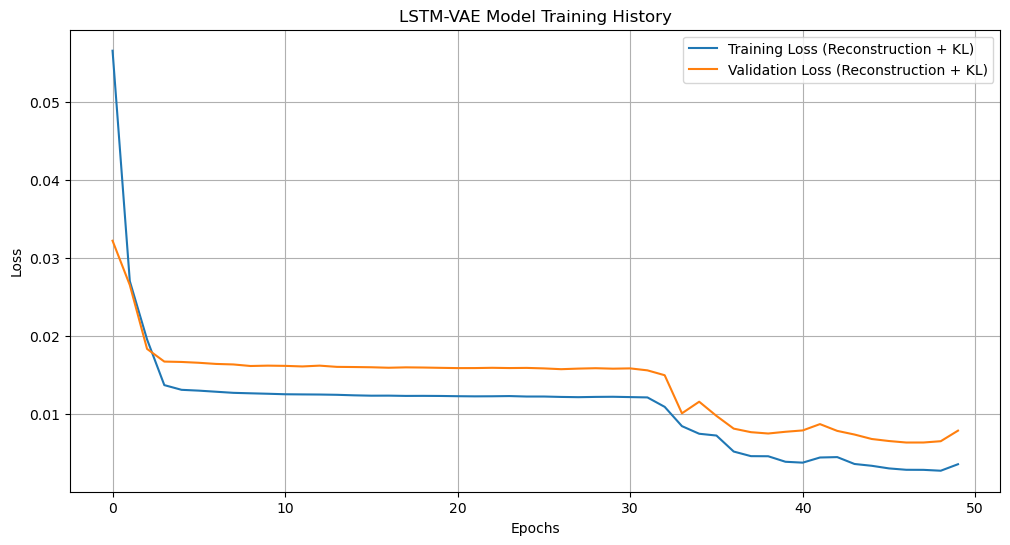


Model saved to prefix: hurricane_lstm_vae_model_v2
Encoder model summary:


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 75, 17)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm_1      │ (None, 75, 64)    │     20,992 │ encoder_input[0]… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm_2      │ (None, 64)        │     33,024 │ encoder_lstm_1[0… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 32)        │      2,080 │ encoder_lstm_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 32)        │      2,080 │ encoder_lstm_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_sampling (Lambda) │ (None, 32)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 58,176 (227.25 KB)

 Trainable params: 58,176 (227.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_latent_input            │ (None, 32)             │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 75, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_1 (LSTM)           │ (None, 75, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_2 (LSTM)           │ (None, 75, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output_timedistributed  │ (None, 75, 17)         │         1,105 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,961 (230.32 KB)

 Trainable params: 58,961 (230.32 KB)

 Non-trainable params: 0 (0.00 B)

LSTM-VAE model loaded successfully.
LSTM-VAE Model loaded successfully from prefix.

Generating a random synthetic hurricane track...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
Generated Random Synthetic Track (first 5 points):
   latitude  longitude  max_wind  min_pressure  ne_34kt_radius  \
0       8.0 -93.859077        20           880               0   
1       8.0 -91.359077        20           880               0   
2       8.0 -88.859077        20           880               0   
3       8.0 -86.359077        20           880               0   
4       8.0 -83.859077        20           880               0   

   se_34kt_radius  sw_34kt_radius  nw_34kt_radius  ne_50kt_radius  \
0              12               0               0               5   
1              14               3               7               7   
2              16               5              17               8   
3              19               7              25               

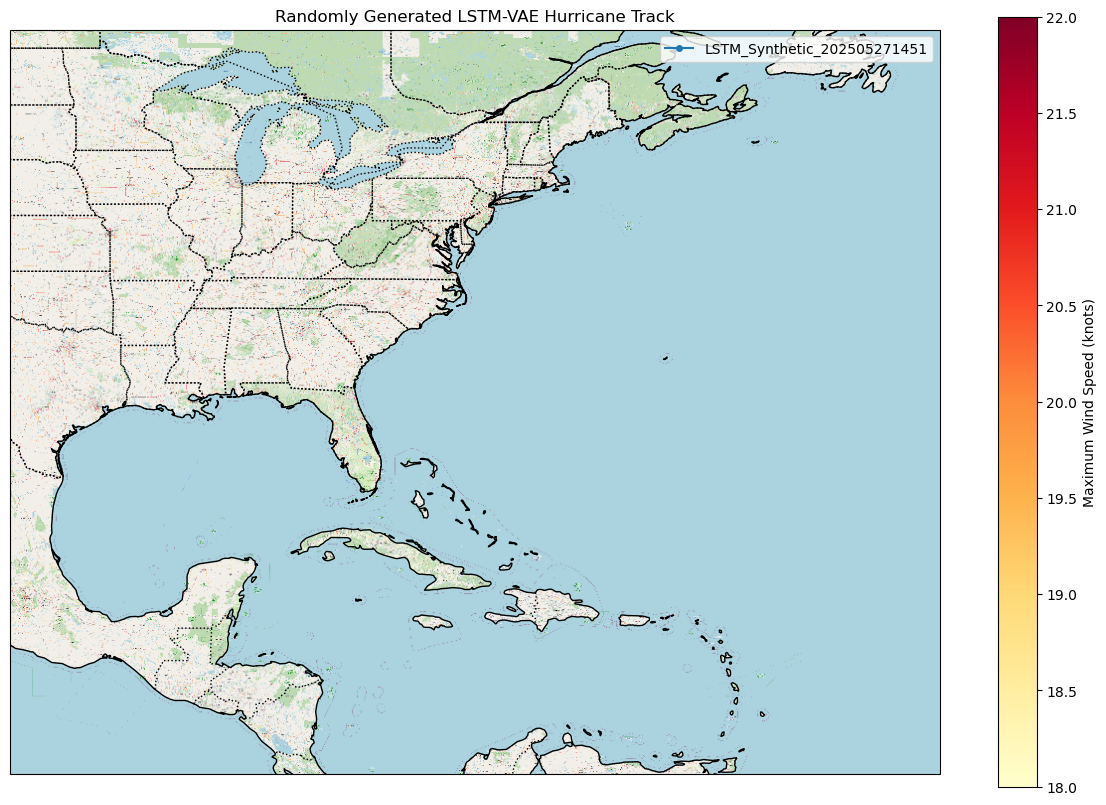


Generating a synthetic hurricane track seeded from: AL182012...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Generated Seeded Synthetic Track (first 5 points):
    latitude  longitude  max_wind  min_pressure  ne_34kt_radius  \
0  16.813904 -50.945644        29           880               6   
1  18.238411 -48.768478        36           972               5   
2  18.607447 -49.353050        41           996               5   
3  18.518110 -50.672928        43           984               6   
4  18.423449 -51.720249        46           967               7   

   se_34kt_radius  sw_34kt_radius  nw_34kt_radius  ne_50kt_radius  \
0              18               4              13               5   
1              16               2               4               5   
2              12               0               0               5   
3               9               1               0    

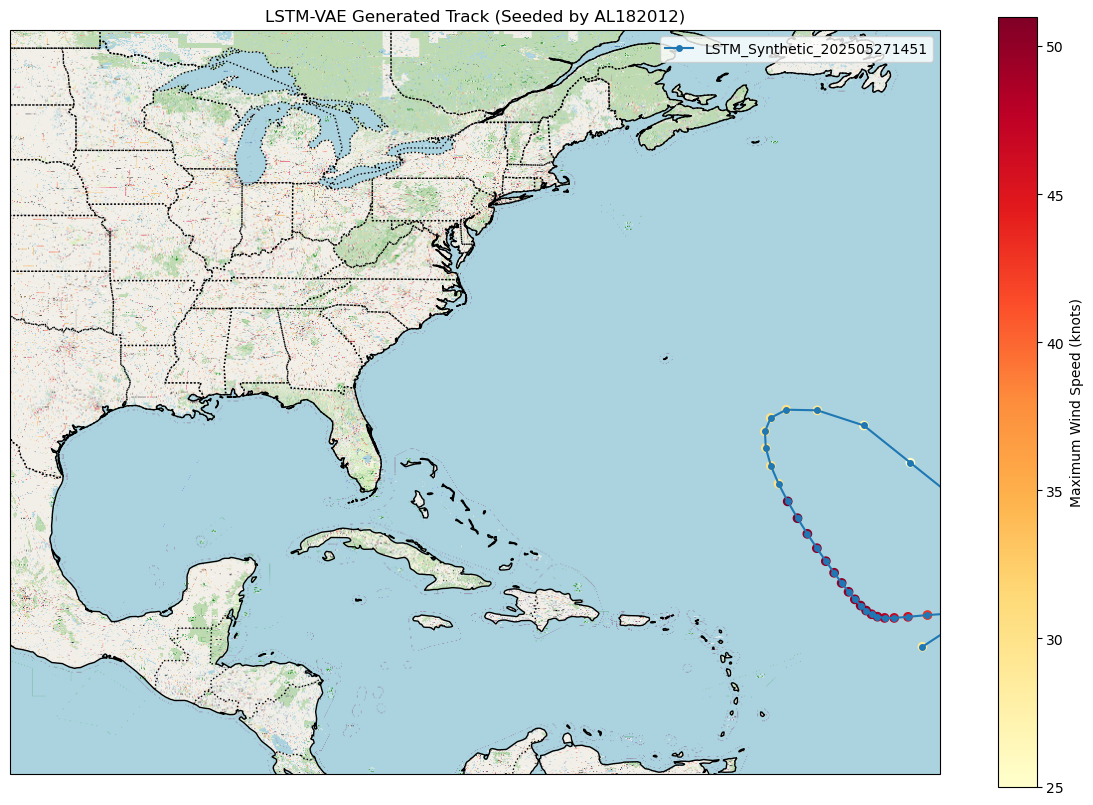

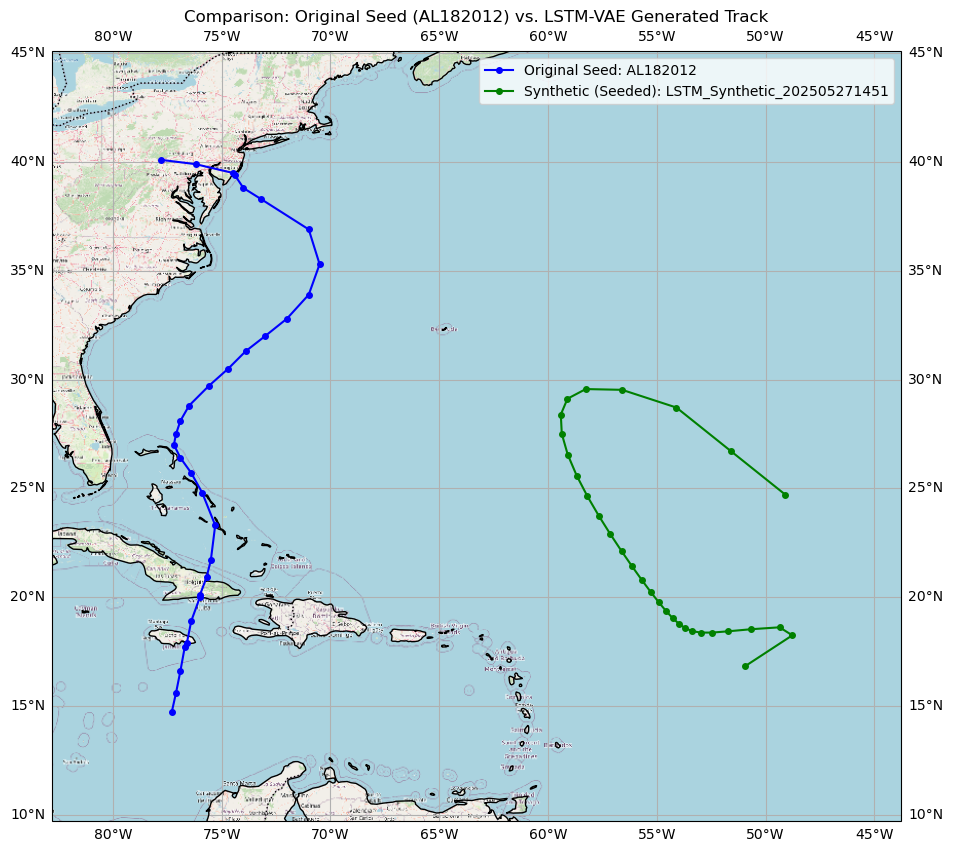

In [14]:
# --- Parameters ---
INPUT_DIM = 17
LATENT_DIM = 32
LSTM_UNITS = 64
EPOCHS = 50
BATCH_SIZE = 32

if not hurricane_sequences:
    print("Error: hurricane_sequences is not defined or empty. Please run the data preparation cells first.")
    FIXED_SEQUENCE_LENGTH = 50
else:
    FIXED_SEQUENCE_LENGTH = max(len(seq) for seq in hurricane_sequences)
    FIXED_SEQUENCE_LENGTH = min(FIXED_SEQUENCE_LENGTH, 75)
    print(f"Using fixed sequence length: {FIXED_SEQUENCE_LENGTH}")

# --- Initialize Model ---
lstm_vae = HurricaneLSTMVAE(
    input_dim=INPUT_DIM,
    latent_dim=LATENT_DIM,
    sequence_length=FIXED_SEQUENCE_LENGTH,
    lstm_units=LSTM_UNITS
)

if 'hurricane_sequences' in locals() and hurricane_sequences:
    print(f"\nTraining LSTM-VAE with {len(hurricane_sequences)} sequences...")
    history = lstm_vae.train(
        hurricane_sequences,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.2
    )

    if history:
        plt.figure(figsize=(12, 6))
        plt.plot(history.history['loss'], label='Training Loss (Reconstruction + KL)')
        plt.plot(history.history['val_loss'], label='Validation Loss (Reconstruction + KL)')
        if 'kl_loss' in history.history:
             plt.plot(history.history['kl_loss'], label='Training KL Loss (metric)')
        if 'val_kl_loss' in history.history:
             plt.plot(history.history['val_kl_loss'], label='Validation KL Loss (metric)')
        plt.title('LSTM-VAE Model Training History')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

    MODEL_SAVE_PATH = 'hurricane_lstm_vae_model_v2'
    lstm_vae.save_model(MODEL_SAVE_PATH)
    print(f"\nModel saved to prefix: {MODEL_SAVE_PATH}")

    loaded_lstm_vae = HurricaneLSTMVAE(
        input_dim=INPUT_DIM,
        latent_dim=LATENT_DIM,
        sequence_length=FIXED_SEQUENCE_LENGTH,
        lstm_units=LSTM_UNITS
    )
    loaded_lstm_vae.load_model(MODEL_SAVE_PATH)
    print("LSTM-VAE Model loaded successfully from prefix.")

    # --- Generate Synthetic Hurricane Tracks using the new class ---
    print("\nGenerating a random synthetic hurricane track...")
    random_synthetic = SyntheticHurricane.generate(
        loaded_lstm_vae,
        num_points=FIXED_SEQUENCE_LENGTH,
        randomness=0.8
    )
    print("Generated Random Synthetic Track (first 5 points):")
    print(random_synthetic.track_df.head())
    random_synthetic.plot(title="Randomly Generated LSTM-VAE Hurricane Track")

    if hurricane_sequences:
        seed_index = 778
        if seed_index < len(hurricane_sequences):
            seed_track_raw_features = hurricane_sequences[seed_index]
            original_seed_id = hurricane_ids[seed_index]
            print(f"\nGenerating a synthetic hurricane track seeded from: {original_seed_id}...")
            seeded_synthetic = SyntheticHurricane.generate(
                loaded_lstm_vae,
                seed_features=seed_track_raw_features,
                num_points=FIXED_SEQUENCE_LENGTH,
                randomness=0.3
            )
            print("Generated Seeded Synthetic Track (first 5 points):")
            print(seeded_synthetic.track_df.head())
            seeded_synthetic.plot(title=f"LSTM-VAE Generated Track (Seeded by {original_seed_id})")

            # For comparison, plot the original seed
            original_seed_df = pd.DataFrame(
                seed_track_raw_features,
                columns=[
                    'latitude', 'longitude', 'max_wind', 'min_pressure',
                    'ne_34kt_radius', 'se_34kt_radius', 'sw_34kt_radius', 'nw_34kt_radius',
                    'ne_50kt_radius', 'se_50kt_radius', 'sw_50kt_radius', 'nw_50kt_radius',
                    'ne_64kt_radius', 'se_64kt_radius', 'sw_64kt_radius', 'nw_64kt_radius',
                    'radius_max_wind'
                ]
            )
            original_seed_df['storm_name'] = f"Original_{original_seed_id}"
            original_seed_df['datetime'] = [datetime.now() + timedelta(hours=i*6) for i in range(len(original_seed_df))]
            fig_comp = plt.figure(figsize=(14, 10))
            ax_comp = plt.axes(projection=ccrs.PlateCarree())
            ax_comp.add_feature(cfeature.COASTLINE, zorder=3)
            ax_comp.add_feature(cfeature.BORDERS, linestyle=':', zorder=3)
            all_lons = pd.concat([original_seed_df['longitude'], seeded_synthetic.track_df['longitude']])
            all_lats = pd.concat([original_seed_df['latitude'], seeded_synthetic.track_df['latitude']])
            ax_comp.set_extent([all_lons.min() - 5, all_lons.max() + 5, 
                                all_lats.min() - 5, all_lats.max() + 5], crs=ccrs.PlateCarree())
            try:
                osm_tiles_comp = cimgt.OSM()
                ax_comp.add_image(osm_tiles_comp, 6, zorder=1)
            except Exception:
                pass
            ax_comp.plot(original_seed_df['longitude'], original_seed_df['latitude'],
                         '-o', color='blue', markersize=4, transform=ccrs.Geodetic(), 
                         label=f"Original Seed: {original_seed_id}", zorder=4)
            ax_comp.plot(seeded_synthetic.track_df['longitude'], seeded_synthetic.track_df['latitude'],
                         '-o', color='green', markersize=4, transform=ccrs.Geodetic(), 
                         label=f"Synthetic (Seeded): {seeded_synthetic.storm_name}", zorder=5)
            ax_comp.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, zorder=2)
            plt.title(f"Comparison: Original Seed ({original_seed_id}) vs. LSTM-VAE Generated Track")
            plt.legend()
            plt.show()
        else:
            print(f"Seed index {seed_index} is out of bounds for hurricane_sequences (length {len(hurricane_sequences)}). Skipping seeded generation.")
    else:
        print("No hurricane_sequences available to use as a seed. Skipping seeded generation.")
else:
    print("Skipping LSTM-VAE training and generation as 'hurricane_sequences' is not available or empty.")

In [1]:
# Enhanced Hurricane Generation with Better Trajectory Conditioning

class HurricaneLSTMVAE_Enhanced(HurricaneLSTMVAE):
    """Enhanced LSTM-VAE with improved trajectory conditioning for more realistic synthetic hurricanes"""
    
    def generate_hurricane_with_trajectory_conditioning(self, num_points=None, seed_hurricane_features=None, 
                                                       randomness=0.3, trajectory_weight=0.7, 
                                                       geographic_conditioning=True):
        """
        Generate a synthetic hurricane with stronger trajectory conditioning
        
        Parameters:
        -----------
        num_points : int
            Number of points to generate
        seed_hurricane_features : array
            Original hurricane track to condition on
        randomness : float
            Amount of randomness (0.0 = exact copy, 1.0 = completely random)
        trajectory_weight : float
            Weight for trajectory conditioning (higher = closer to original path)
        geographic_conditioning : bool
            Whether to apply geographic conditioning during generation
        """
        if num_points is None:
            num_points = self.sequence_length
            
        # Start with the seed if provided
        if seed_hurricane_features is not None:
            seed_data_scaled = self.preprocess_data([seed_hurricane_features])
            z_mean, z_log_var, _ = self.encoder.predict(seed_data_scaled)
            
            # Reduce randomness in latent space for better conditioning
            epsilon = np.random.normal(0, 1, size=z_mean.shape)
            latent_vector = z_mean + np.exp(0.5 * z_log_var) * epsilon * randomness * 0.5
            
            # Generate initial track
            generated_track_scaled = self.decoder.predict(latent_vector)[0]
            generated_track = self.scaler.inverse_transform(generated_track_scaled)
            
            # Apply trajectory conditioning - blend with original track
            if trajectory_weight > 0:
                original_track = seed_hurricane_features[:min(len(seed_hurricane_features), len(generated_track))]
                blend_length = min(len(original_track), len(generated_track))
                
                for i in range(blend_length):
                    # Stronger conditioning for lat/lon (geographical position)
                    geo_weight = trajectory_weight * 1.2  # Even stronger for position
                    generated_track[i, 0] = (geo_weight * original_track[i, 0] + 
                                           (1 - geo_weight) * generated_track[i, 0])  # latitude
                    generated_track[i, 1] = (geo_weight * original_track[i, 1] + 
                                           (1 - geo_weight) * generated_track[i, 1])  # longitude
                    
                    # Moderate conditioning for intensity features
                    intensity_weight = trajectory_weight * 0.8
                    generated_track[i, 2] = (intensity_weight * original_track[i, 2] + 
                                           (1 - intensity_weight) * generated_track[i, 2])  # max_wind
                    generated_track[i, 3] = (intensity_weight * original_track[i, 3] + 
                                           (1 - intensity_weight) * generated_track[i, 3])  # min_pressure
                    
                    # Light conditioning for other features
                    other_weight = trajectory_weight * 0.5
                    for j in range(4, min(generated_track.shape[1], original_track.shape[1])):
                        generated_track[i, j] = (other_weight * original_track[i, j] + 
                                               (1 - other_weight) * generated_track[i, j])
        else:
            # Random generation if no seed provided
            latent_vector = np.random.normal(0, 1, size=(1, self.latent_dim))
            generated_track_scaled = self.decoder.predict(latent_vector)[0]
            generated_track = self.scaler.inverse_transform(generated_track_scaled)
        
        if num_points and num_points < len(generated_track):
            generated_track = generated_track[:num_points]
        
        # Create DataFrame
        columns = [
            'latitude', 'longitude', 'max_wind', 'min_pressure',
            'ne_34kt_radius', 'se_34kt_radius', 'sw_34kt_radius', 'nw_34kt_radius',
            'ne_50kt_radius', 'se_50kt_radius', 'sw_50kt_radius', 'nw_50kt_radius',
            'ne_64kt_radius', 'se_64kt_radius', 'sw_64kt_radius', 'nw_64kt_radius',
            'radius_max_wind'
        ]
        track_df = pd.DataFrame(generated_track, columns=columns[:self.input_dim])
        start_date = datetime.now()
        track_df['datetime'] = [start_date + timedelta(hours=i*6) for i in range(len(track_df))]
        track_df['year'] = track_df['datetime'].dt.year
        track_df['month'] = track_df['datetime'].dt.month
        track_df['day'] = track_df['datetime'].dt.day
        track_df['hour'] = track_df['datetime'].dt.hour
        track_df['minute'] = 0
        track_df['status'] = 'HU'
        track_df['full_id'] = 'LSTM_ENH_' + start_date.strftime('%Y%m%d%H%M')
        track_df['storm_name'] = 'LSTM_Enhanced_' + start_date.strftime('%Y%m%d%H%M')
        
        # Post-process and apply constraints
        track_df = self._postprocess_generated_track(track_df)
        
        if geographic_conditioning:
            track_df = self.apply_enhanced_geographic_constraints(track_df, seed_hurricane_features)
        
        return track_df
    
    def _postprocess_generated_track(self, track_df):
        """Post-process generated track with proper value ranges"""
        df = track_df.copy()
        
        # Round and clip features
        if 'max_wind' in df.columns:
            df['max_wind'] = df['max_wind'].round().astype(int)
            df['max_wind'] = np.clip(df['max_wind'], 25, 180)
        if 'min_pressure' in df.columns:
            df['min_pressure'] = df['min_pressure'].round().astype(int)
            df['min_pressure'] = np.clip(df['min_pressure'], 880, 1020)
        
        # Clip radius values
        for col in [
            'ne_34kt_radius', 'se_34kt_radius', 'sw_34kt_radius', 'nw_34kt_radius',
            'ne_50kt_radius', 'se_50kt_radius', 'sw_50kt_radius', 'nw_50kt_radius',
            'ne_64kt_radius', 'se_64kt_radius', 'sw_64kt_radius', 'nw_64kt_radius',
            'radius_max_wind'
        ]:
            if col in df.columns:
                df[col] = df[col].round().astype(int)
                df[col] = np.clip(df[col], 0, 400)
        
        return df
    
    def apply_enhanced_geographic_constraints(self, track_df, seed_features=None):
        """Apply enhanced geographic constraints with reference to seed track"""
        df = track_df.copy()
        
        # Define realistic movement constraints based on seed track if available
        if seed_features is not None and len(seed_features) > 1:
            # Calculate typical movement patterns from seed
            seed_lat_diffs = np.diff(seed_features[:, 0])  # latitude changes
            seed_lon_diffs = np.diff(seed_features[:, 1])  # longitude changes
            
            avg_lat_movement = np.mean(np.abs(seed_lat_diffs))
            avg_lon_movement = np.mean(np.abs(seed_lon_diffs))
            
            # Use seed-based movement constraints
            max_lat_change = max(1.0, avg_lat_movement * 2.0)  # Allow some variation
            max_lon_change = max(1.5, avg_lon_movement * 2.0)
        else:
            # Default constraints
            max_lat_change = 2.0
            max_lon_change = 2.5
        
        # Apply trajectory smoothing with seed-aware constraints
        for i in range(1, len(df)):
            lat_diff = abs(df.loc[i, 'latitude'] - df.loc[i-1, 'latitude'])
            lon_diff = abs(df.loc[i, 'longitude'] - df.loc[i-1, 'longitude'])
            
            if lat_diff > max_lat_change:
                df.loc[i, 'latitude'] = df.loc[i-1, 'latitude'] + np.sign(df.loc[i, 'latitude'] - df.loc[i-1, 'latitude']) * max_lat_change
            
            if lon_diff > max_lon_change:
                df.loc[i, 'longitude'] = df.loc[i-1, 'longitude'] + np.sign(df.loc[i, 'longitude'] - df.loc[i-1, 'longitude']) * max_lon_change
        
        # Apply basin boundaries (more restrictive)
        df['latitude'] = np.clip(df['latitude'], 8.0, 50.0)
        df['longitude'] = np.clip(df['longitude'], -100.0, -15.0)  # Prevent African extension
        
        # Apply physical constraints
        df = self._apply_storm_development_logic(df)
        
        return df

# Create enhanced model instance using the existing trained model
enhanced_lstm_vae = HurricaneLSTMVAE_Enhanced(
    input_dim=INPUT_DIM,
    latent_dim=LATENT_DIM,
    sequence_length=FIXED_SEQUENCE_LENGTH,
    lstm_units=LSTM_UNITS
)

# Load the trained model weights
enhanced_lstm_vae.load_model(MODEL_SAVE_PATH)
print("Enhanced LSTM-VAE model loaded successfully.")

NameError: name 'HurricaneLSTMVAE' is not defined

In [ ]:
# Generate improved synthetic hurricanes with better trajectory conditioning
if hurricane_sequences and seed_index < len(hurricane_sequences):
    seed_track_raw_features = hurricane_sequences[seed_index]
    original_seed_id = hurricane_ids[seed_index]
    
    print(f"\nGenerating enhanced synthetic hurricanes seeded from: {original_seed_id}...")
    
    # Generate with different trajectory conditioning strengths
    trajectory_weights = [0.9, 0.7, 0.5]  # Strong, medium, light conditioning
    enhanced_synthetics = []
    
    for i, traj_weight in enumerate(trajectory_weights):
        print(f"\nGenerating synthetic hurricane with trajectory weight: {traj_weight}")
        
        enhanced_synthetic = enhanced_lstm_vae.generate_hurricane_with_trajectory_conditioning(
            seed_hurricane_features=seed_track_raw_features,
            num_points=min(32, FIXED_SEQUENCE_LENGTH),  # Match original length
            randomness=0.2,  # Low randomness for better conditioning
            trajectory_weight=traj_weight,
            geographic_conditioning=True
        )
        
        # Convert to SyntheticHurricane object
        synthetic_obj = SyntheticHurricane(enhanced_synthetic)
        synthetic_obj.storm_name = f"Enhanced_TW{traj_weight}_{original_seed_id}"
        enhanced_synthetics.append((traj_weight, synthetic_obj))
        
        print(f"Generated track length: {len(enhanced_synthetic)}")
        print(f"Track bounds: Lat [{enhanced_synthetic['latitude'].min():.1f}, {enhanced_synthetic['latitude'].max():.1f}], "
              f"Lon [{enhanced_synthetic['longitude'].min():.1f}, {enhanced_synthetic['longitude'].max():.1f}]")
    
    # Create comprehensive comparison plot
    fig = plt.figure(figsize=(16, 12))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, zorder=3)
    ax.add_feature(cfeature.BORDERS, linestyle=':', zorder=3)
    ax.add_feature(cfeature.STATES, linestyle=':', zorder=3)
    
    # Calculate bounds including all tracks
    all_lats = [original_seed_df['latitude']]
    all_lons = [original_seed_df['longitude']]
    
    for _, synth_obj in enhanced_synthetics:
        all_lats.append(synth_obj.track_df['latitude'])
        all_lons.append(synth_obj.track_df['longitude'])
    
    combined_lats = pd.concat(all_lats)
    combined_lons = pd.concat(all_lons)
    
    ax.set_extent([combined_lons.min() - 3, combined_lons.max() + 3, 
                   combined_lats.min() - 2, combined_lats.max() + 2], crs=ccrs.PlateCarree())
    
    try:
        osm_tiles = cimgt.OSM()
        ax.add_image(osm_tiles, 6, zorder=1)
    except Exception:
        pass
    
    # Plot original seed track
    ax.plot(original_seed_df['longitude'], original_seed_df['latitude'],
            '-o', color='blue', markersize=6, linewidth=3, transform=ccrs.Geodetic(), 
            label=f"Original: {original_seed_id}", zorder=4)
    
    # Plot enhanced synthetic tracks with different colors
    colors = ['green', 'orange', 'red']
    for i, (traj_weight, synth_obj) in enumerate(enhanced_synthetics):
        ax.plot(synth_obj.track_df['longitude'], synth_obj.track_df['latitude'],
                '-o', color=colors[i], markersize=4, linewidth=2, alpha=0.8,
                transform=ccrs.Geodetic(), 
                label=f"Enhanced TW={traj_weight}", zorder=5+i)
    
    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, zorder=2)
    plt.title(f"Enhanced Trajectory Conditioning: Original vs Synthetic Tracks\nSeed: {original_seed_id}")
    plt.legend(loc='upper right')
    plt.show()
    
    # Show detailed comparison for the best conditioned track
    best_synthetic = enhanced_synthetics[0][1]  # Highest trajectory weight
    
    print(f"\nDetailed comparison - Original vs Best Enhanced Synthetic:")
    print(f"Original track length: {len(original_seed_df)}")
    print(f"Synthetic track length: {len(best_synthetic.track_df)}")
    
    # Calculate track similarity metrics
    min_len = min(len(original_seed_df), len(best_synthetic.track_df))
    
    lat_diff = np.mean(np.abs(original_seed_df['latitude'][:min_len] - best_synthetic.track_df['latitude'][:min_len]))
    lon_diff = np.mean(np.abs(original_seed_df['longitude'][:min_len] - best_synthetic.track_df['longitude'][:min_len]))
    wind_diff = np.mean(np.abs(original_seed_df['max_wind'][:min_len] - best_synthetic.track_df['max_wind'][:min_len]))
    
    print(f"\nSimilarity Metrics (Mean Absolute Differences):")
    print(f"Latitude difference: {lat_diff:.2f} degrees (~{lat_diff*111:.0f} km)")
    print(f"Longitude difference: {lon_diff:.2f} degrees")
    print(f"Wind speed difference: {wind_diff:.1f} knots")
    
    # Plot individual enhanced synthetic track
    best_synthetic.plot(title=f"Enhanced Synthetic Hurricane (TW=0.9, Seed: {original_seed_id})")
    
else:
    print("Cannot generate enhanced synthetic hurricanes: missing seed data.")